Import pandas library and read Customer Churn CSV and display first 5 rows to verify if CSV is loading or not.

In [117]:
import pandas as pd

df = pd.read_csv('TelcoCustomerChurn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [118]:
#Load data types from dictionary for reference
data_dict = pd.read_csv('TelcoCustomerChurn - Data Dictionary.csv')
data_dict

,Column,Data Type,Description,Example / Values
0,customerID,Categorical / ID,Unique identifier for each customer,7590-VHVEG
1,gender,Categorical,Gender of the customer,"Male, Female"
2,SeniorCitizen,Numerical / Binary,Indicates whether the customer is a senior cit...,"0, 1"
3,Partner,Categorical,Whether the customer has a partner,"Yes, No"
4,Dependents,Categorical,Whether the customer has dependents,"Yes, No"
5,tenure,Numerical,Number of months the customer has been with th...,"1, 24, 72"
6,PhoneService,Categorical,Whether the customer has phone service,"Yes, No"
7,MultipleLines,Categorical,Whether the customer has multiple phone lines,"Yes, No, No phone service"
8,InternetService,Categorical,Type of internet service subscribed to,"DSL, Fiber optic, No"
9,OnlineSecurity,Categorical,Whether the customer has online security service,"Yes, No, No internet service"


# Data type and structure checks

In [119]:
# Get shapes, datatypes and datatypes info for customer churn CSV
print("Shape of data (rows, columns): ", df.shape)
print()
print("Data Types: ", df.dtypes)
print()
print("Total Data type info: ")
df.info()

Shape of data (rows, columns):  (7043, 21)

Data Types:  customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Total Data type info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen    

Total Charges should be Integer but it's showing object type means there might be some null or empty values here.

In [120]:
#Find missing value per column
print('Missing values per column')
print(df.isnull().sum())

#convert total charges to number value from object type. Check if conversion fails
missing_total_charges = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]
print(f"Rows that failed conversion to number: {len(missing_total_charges)}")
print("\n Bad rows that failed to convert")
missing_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Missing values per column
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Rows that failed conversion to number: 11

 Bad rows that failed to convert


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Conclusion for **Missing value analysis** **For bad rows that failed conversion Total charges and tenure is 0 meaning customer with 0 tenure hasn't been billed yet.**

So, let's convert data type and put 0 instead of blank since tenure is already 0.

In [121]:
# Convert TotalCharges to numeric, turning failed conversions into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now fill those NaNs with 0 — logically justified since they all have tenure=0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm the fix
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isna().sum(), "missing values remaining")

float64
0 missing values remaining


Now, we have 0 missing values.

In [122]:
#Duplicate check
print("Fully duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

Fully duplicate rows: 0
Duplicate customerIDs: 0


In [123]:
#Numerical vs categorical split
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [124]:
# Corrected groupings based on actual meaning, not just dtype
target_col = 'Churn'
id_col = 'customerID'

categorical_cols.remove('customerID')
categorical_cols.remove('Churn')
categorical_cols.append('SeniorCitizen')

#Remove senior citizen from numerical_cols because we identified it as categorical
numerical_cols.remove('SeniorCitizen')

print("ID column (exclude from model):", id_col)
print("Target column:", target_col)
print("True numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

ID column (exclude from model): customerID
Target column: Churn
True numerical columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']


In [125]:
#Target Variable analysis
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(4) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


We will do splitting (stratified) first before encoding to handle class imbalance

***Class imbalance handling was applied only to the training set to preserve the test set's real-world class distribution and avoid data leakage.***

In [126]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']


# spliting 70:30 as per recommendation im assignment and using random state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Train churn distribution:")
print(y_train.value_counts(normalize=True).round(4) * 100)
print()
print("Test churn distribution:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Train shape: (4930, 19)
Test shape: (2113, 19)

Train churn distribution:
Churn
No     73.47
Yes    26.53
Name: proportion, dtype: float64

Test churn distribution:
Churn
No     73.45
Yes    26.55
Name: proportion, dtype: float64


Now, moving to encoding. We will do this on our training data and later applied on test data.

In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

print(categorical_cols)
print(numerical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_cols)
    ],
    remainder='passthrough'
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

y_train_encoded = y_train.map({'No': 0, 'Yes': 1})
y_test_encoded = y_test.map({'No': 0, 'Yes': 1})

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)
print()
print("y_train_encoded distribution:")
print(y_train_encoded.value_counts())
print()
print("y_test_encoded distribution:")
print(y_test_encoded.value_counts())

print("\nChurn rate in train:", y_train_encoded.mean().round(3))
print("Churn rate in test:",  y_test_encoded.mean().round(3))

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']
['tenure', 'MonthlyCharges', 'TotalCharges']
X_train_encoded shape: (4930, 40)
X_test_encoded shape: (2113, 40)

y_train_encoded distribution:
Churn
0    3622
1    1308
Name: count, dtype: int64

y_test_encoded distribution:
Churn
0    1552
1     561
Name: count, dtype: int64

Churn rate in train: 0.265
Churn rate in test: 0.265


## 1. Data Understanding & Preprocessing — Summary

**Dataset:** Telco Customer Churn — 7,043 rows × 21 columns, no duplicate rows.

**Target variable:** `Churn` (Yes/No), imbalanced — 73.46% No, 26.54% Yes.
This imbalance means accuracy alone will be misleading; we will emphasize Recall and F1.

**Data Quality Issues Found:**
- `TotalCharges` was stored as `object` because 11 rows contained a blank space `" "`.
  These 11 rows all had `tenure = 0` (new customers who had not been billed yet).
- Handled by: `pd.to_numeric(errors='coerce')` → `fillna(0)` → final shape 7,043 rows with no empty Total Charges.
- Chose to convert empty total charges to 0 for tenure 0 because 11/7043 = 0.15% is negligible.

**Preprocessing Decisions:**
- Dropped `customerID` — unique identifier, no predictive value.
- Encoded target as 0/1 (No=0, Yes=1).
- One-hot encoded all 15 categorical features with `drop_first=True`
  to avoid the dummy-variable trap.
- `SeniorCitizen` kept as-is (already binary 0/1).

**Train/Test Split:**
- 70/30 split, `random_state=42` for reproducibility.
- `stratify=y` preserves the 26.54% churn rate in both train and test —
  verified: train churn = 0.266, test churn = 0.265.

# Exploratory Data Analysis - Start

We will plot 2 charts
- Churn distribution
- Churn by contract type

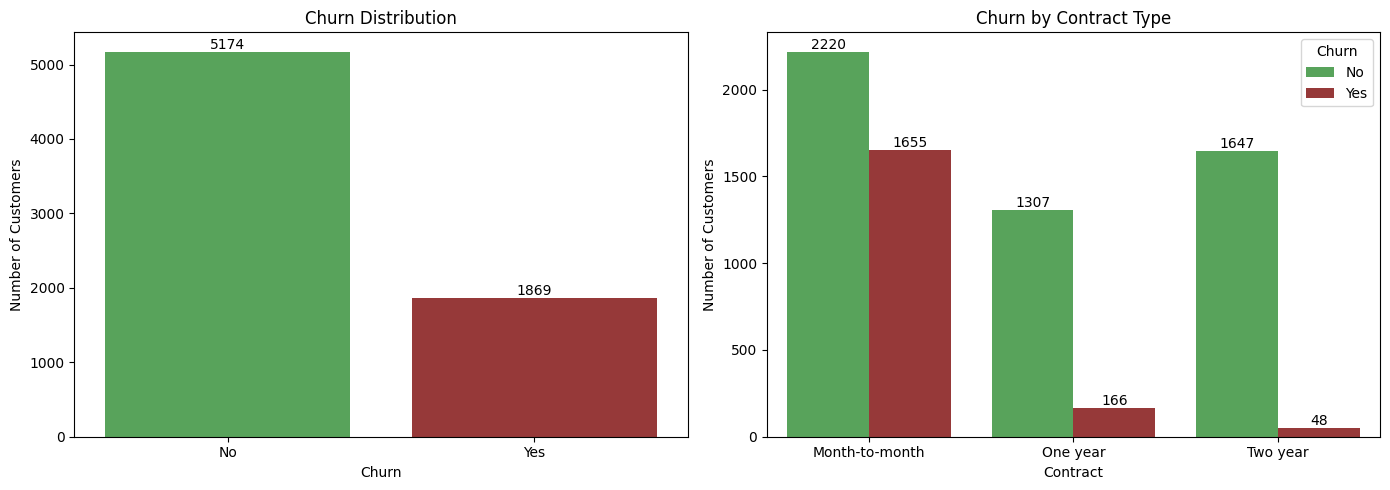

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Churn distribution
sns.countplot(data=df, x='Churn', hue='Churn', ax=axes[0], palette=['#4CAF50', '#A52A2A'])
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Number of Customers')
for container in axes[0].containers:
    axes[0].bar_label(container)

# Chart 2: Churn by Contract type
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1], palette=['#4CAF50', '#A52A2A'])
axes[1].set_title('Churn by Contract Type')
axes[1].set_ylabel('Number of Customers')
for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()
plt.show()

We can see Month-to-Month customer has better churn rate.

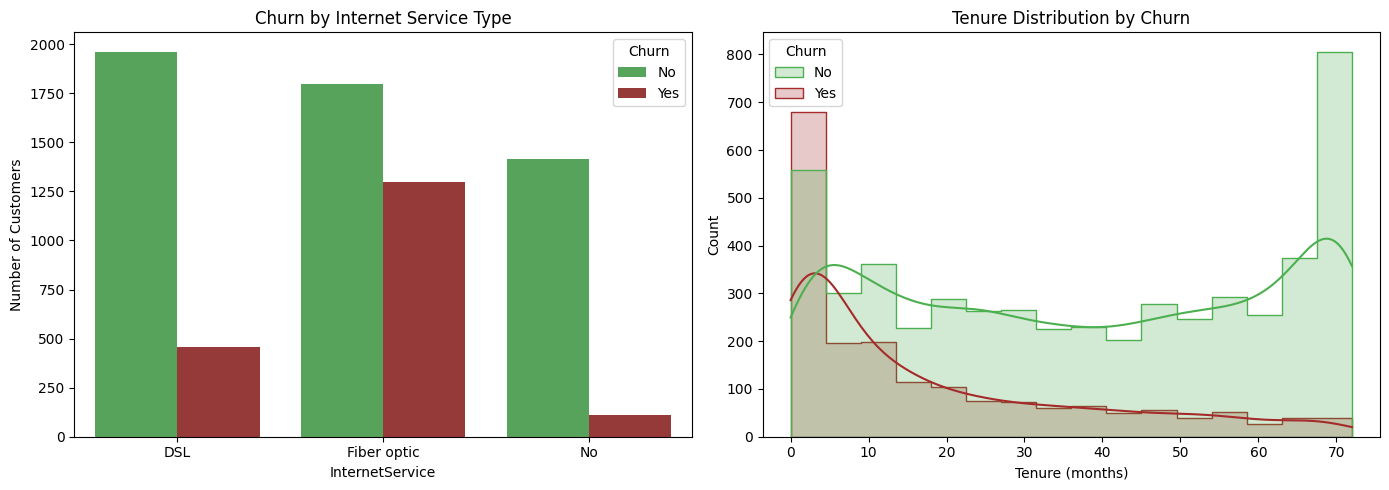

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


In [129]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 3: Churn by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0], palette=['#4CAF50', '#A52A2A'])
axes[0].set_title('Churn by Internet Service Type')
axes[0].set_ylabel('Number of Customers')

# Chart 4: Tenure distribution by Churn (histogram, overlaid)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[1], palette=['#4CAF50', '#A52A2A'], element='step')
axes[1].set_title('Tenure Distribution by Churn')
axes[1].set_xlabel('Tenure (months)')

plt.tight_layout()
plt.show()

# Exact churn rate per Internet Service type
internet_churn_rate = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
print(internet_churn_rate.round(2))

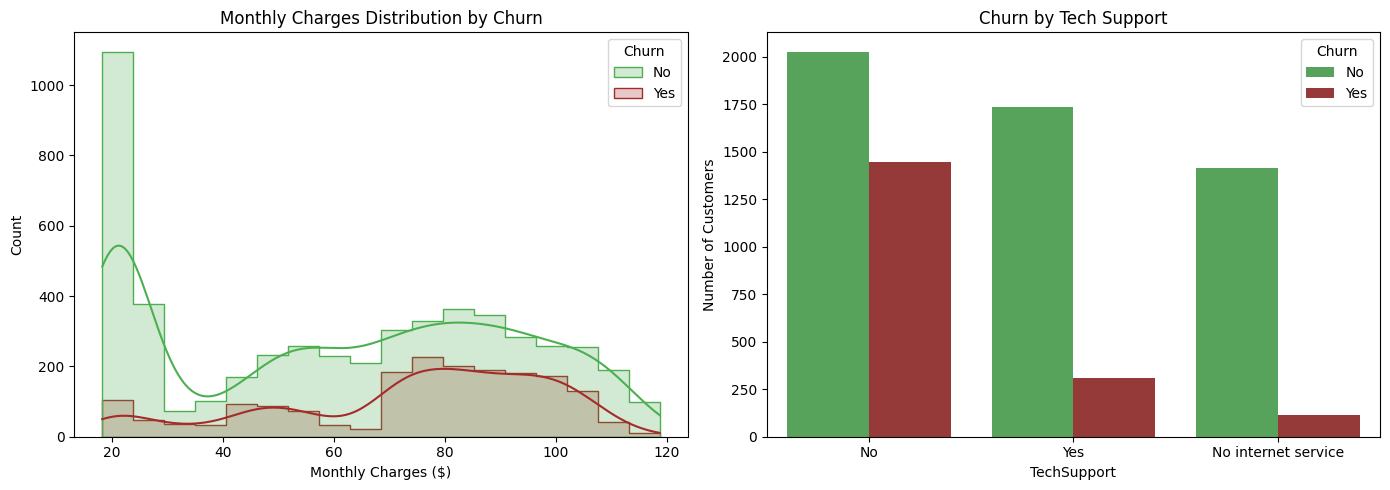

Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 5: MonthlyCharges distribution by Churn
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[0], palette=['#4CAF50', '#A52A2A'], element='step')
axes[0].set_title('Monthly Charges Distribution by Churn')
axes[0].set_xlabel('Monthly Charges ($)')

# Chart 6: Churn by TechSupport
sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[1], palette=['#4CAF50', '#A52A2A'])
axes[1].set_title('Churn by Tech Support')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

techsupport_churn_rate = df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100
print(techsupport_churn_rate.round(2))

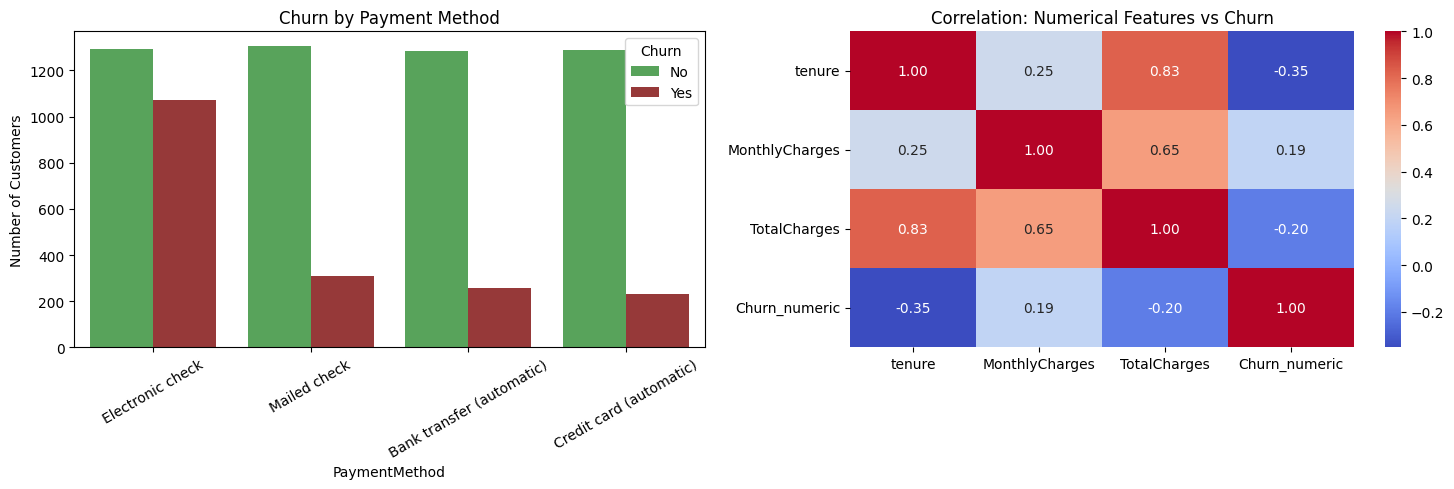

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 7: Churn by Payment Method
sns.countplot(data=df, x='PaymentMethod', hue='Churn', ax=axes[0], palette=['#4CAF50', '#A52A2A'])
axes[0].set_title('Churn by Payment Method')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)

# Chart 8: Correlation heatmap of numerical features
numerical_with_target = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numerical_with_target['Churn_numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})

sns.heatmap(numerical_with_target.corr(), annot=True, cmap='coolwarm', ax=axes[1], fmt='.2f')
axes[1].set_title('Correlation: Numerical Features vs Churn')

plt.tight_layout()
plt.show()

## 2. Exploratory Data Analysis — Key Findings

1. **Class imbalance:** Only 26.5% of customers churn overall — moderate class imbalance to account for in modeling.
2. **Contract type is the biggest categorical driver:** Month-to-month contracts churn at ~43%, vs. ~11% (one year) and ~3% (two year) — commitment strongly reduces churn.
3. **Tenure matters most:** Churned customers cluster heavily in early tenure (first ~12 months) — the highest-risk window is right after signup.
4. **Fiber optic customers churn at ~42%** , nearly double DSL's ~19% — likely price/reliability dissatisfaction.
5. **Higher monthly charges correlate with churn.** - price sensitivity is a real driver
6. **Tech Support correlations:** Customers without TechSupport churn more than those with it — proactive support is a retention lever.
7. **Churn by payment method:** Electronic check has highest churn rate.
8. **Correlation heatmap:** tenure has the strongest (negative) correlation with churn; tenure and TotalCharges are highly correlated with each other.

# Feature Engineering

In [132]:
#Tenure Group

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 100],
    labels=['0-12 months (New)', '13-24 months (Established)', '25-48 months (Loyal)', '48+ months (Very Loyal)']
)

print(df.groupby('TenureGroup', observed=True)['Churn'].value_counts(normalize=True).unstack().round(3) * 100)
print()
print("Churn rate per tenure_group:")
print(df.groupby('TenureGroup', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean()).round(3))

Churn                         No   Yes
TenureGroup                           
0-12 months (New)           52.6  47.4
13-24 months (Established)  71.3  28.7
25-48 months (Loyal)        79.6  20.4
48+ months (Very Loyal)     90.5   9.5

Churn rate per tenure_group:
TenureGroup
0-12 months (New)             0.474
13-24 months (Established)    0.287
25-48 months (Loyal)          0.204
48+ months (Very Loyal)       0.095
Name: Churn, dtype: float64


In [133]:
#Average Monthly Spend
import numpy as np

df['AvgMonthlySpend'] = np.where(
    df['tenure'] == 0,
    df['MonthlyCharges'],
    df['TotalCharges'] / df['tenure']
)

# Bucket into quartiles to see the churn relationship clearly
df['AvgMonthlySpendGroup'] = pd.qcut(df['AvgMonthlySpend'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

print(df.groupby('AvgMonthlySpendGroup', observed=True)['Churn'].value_counts(normalize=True).unstack().round(3) * 100)

Churn                   No   Yes
AvgMonthlySpendGroup            
Low                   88.8  11.2
Medium                74.7  25.3
High                  63.7  36.3
Very High             66.6  33.4


In [134]:
#Number of additional services subscribed
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['NumAdditionalServices'] = (df[service_cols] == 'Yes').sum(axis=1)

print(df.groupby('NumAdditionalServices')['Churn'].value_counts(normalize=True).unstack().round(3) * 100)

Churn                    No   Yes
NumAdditionalServices            
0                      78.6  21.4
1                      54.2  45.8
2                      64.2  35.8
3                      72.6  27.4
4                      77.7  22.3
5                      87.6  12.4
6                      94.7   5.3


In [135]:
# High risk profile based on electronic check and month to month churn rates

df['IsHighRiskProfile'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)

print(df.groupby('IsHighRiskProfile')['Churn'].value_counts(normalize=True).unstack().round(3) * 100)

Churn                No   Yes
IsHighRiskProfile            
0                  83.2  16.8
1                  46.3  53.7


In [136]:
import numpy as np

def add_engineered_features(data):
    """Adds all 4 engineered features. Works on any dataframe with the required raw columns.
    No printing here — this only transforms data, so it works on X_train, X_test, or new API data."""
    data = data.copy()

    data['TenureGroup'] = pd.cut(
        data['tenure'], bins=[-1, 12, 24, 48, 100],
        labels=['0-12 months (New)', '13-24 months (Established)', '25-48 months (Loyal)', '48+ months (Very Loyal)']
    )

    data['AvgMonthlySpend'] = np.where(
        data['tenure'] == 0, data['MonthlyCharges'], data['TotalCharges'] / data['tenure']
    )

    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    data['NumAdditionalServices'] = (data[service_cols] == 'Yes').sum(axis=1)

    data['IsHighRiskProfile'] = (
        (data['Contract'] == 'Month-to-month') & (data['PaymentMethod'] == 'Electronic check')
    ).astype(int)

    return data

# Apply to the full df (for EDA/findings you already printed — keep those cells as-is)
df = add_engineered_features(df)

# Apply the SAME function to X_train and X_test
X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)

print("X_train columns now:", list(X_train.columns))

X_train columns now: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'AvgMonthlySpend', 'NumAdditionalServices', 'IsHighRiskProfile']


# Feature Engineering findings

1. TenureGroup

- **How:** Bucketed raw tenure (months) into 4 ranges: 0-12, 13-24, 25-48, 48+.
- Why it may help: EDA showed churn isn't smooth across tenure — it's concentrated early. Bucketing makes this "new customer risk window" an explicit, easy-to-split signal for the model.

2. AvgMonthlySpend

- **How:** Computed as TotalCharges / tenure (with MonthlyCharges as a fallback for tenure=0), then bucketed into quartiles.
- **Why it may help:** tenure and TotalCharges were highly correlated in the EDA heatmap (multicollinearity) — this combines them into one non-redundant signal representing sustained average spend, rather than feeding the model two overlapping numbers.

3. NumAdditionalServices

- **How:** Counted how many of 6 add-on services (Online Security, Backup, Device Protection, Tech Support, Streaming TV/Movies) each customer subscribes to, scored 0–6.
- **Why it may help:** TechSupport alone showed a strong churn difference in EDA — this generalizes that idea into a single "engagement/investment" score across all add-ons, capturing customers who are more embedded in the service ecosystem.

4. IsHighRiskProfile

- **How:** Binary flag = 1 when a customer has both Month-to-month contract and Electronic check payment simultaneously.
- **Why it may help:** Both factors individually showed high churn in EDA (~43% and highest among payment methods respectively) — this tests whether the combination compounds the risk beyond either alone, which the model might not easily discover without an explicit hint.

In [138]:
# Update column lists to include the 4 new engineered features
categorical_cols = categorical_cols + ['TenureGroup']
numerical_cols = numerical_cols + ['AvgMonthlySpend', 'NumAdditionalServices', 'IsHighRiskProfile']

print("Categorical columns now:", categorical_cols)
print("Numerical columns now:", numerical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_cols)
    ],
    remainder='passthrough'
)

# Fit only on train, transform both
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

Categorical columns now: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'TenureGroup']
Numerical columns now: ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'NumAdditionalServices', 'IsHighRiskProfile']
X_train_encoded shape: (4930, 47)
X_test_encoded shape: (2113, 47)


# Model Development

In [145]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

configs = {
    "Model Config 1: Baseline (unrestricted)": DecisionTreeClassifier(
        random_state=42
    ),
    "Model Config 2: Shallow (max_depth=4)": DecisionTreeClassifier(
        max_depth=4, random_state=42
    ),
    "Model Config 3: Moderate depth + balanced": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=20, class_weight='balanced', random_state=42
    ),
    "Model Config 4: Entropy + balanced": DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=20, criterion='entropy', class_weight='balanced', random_state=42
    ),
}

trained_models = {}

for name, model in configs.items():
    model.fit(X_train_encoded, y_train_encoded)
    trained_models[name] = model

    train_acc = accuracy_score(y_train_encoded, model.predict(X_train_encoded))
    test_acc = accuracy_score(y_test_encoded, model.predict(X_test_encoded))

    print(f"{name}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Gap (overfitting signal): {train_acc - test_acc:.4f}")
    print()

Model Config 1: Baseline (unrestricted):
  Train Accuracy: 0.9980
  Test Accuracy:  0.7203
  Gap (overfitting signal): 0.2777

Model Config 2: Shallow (max_depth=4):
  Train Accuracy: 0.7980
  Test Accuracy:  0.7918
  Gap (overfitting signal): 0.0062

Model Config 3: Moderate depth + balanced:
  Train Accuracy: 0.7629
  Test Accuracy:  0.7383
  Gap (overfitting signal): 0.0246

Model Config 4: Entropy + balanced:
  Train Accuracy: 0.7629
  Test Accuracy:  0.7383
  Gap (overfitting signal): 0.0246



In [146]:
# Test models with other model evaluation methods
from sklearn.metrics import classification_report

for name, model in trained_models.items():
    print(f"=== {name} ===")
    preds = model.predict(X_test_encoded)
    print(classification_report(y_test_encoded, preds, target_names=['No Churn', 'Churn']))
    print()

=== Model Config 1: Baseline (unrestricted) ===
              precision    recall  f1-score   support

    No Churn       0.81      0.81      0.81      1552
       Churn       0.47      0.48      0.47       561

    accuracy                           0.72      2113
   macro avg       0.64      0.64      0.64      2113
weighted avg       0.72      0.72      0.72      2113


=== Model Config 2: Shallow (max_depth=4) ===
              precision    recall  f1-score   support

    No Churn       0.82      0.92      0.87      1552
       Churn       0.66      0.45      0.53       561

    accuracy                           0.79      2113
   macro avg       0.74      0.68      0.70      2113
weighted avg       0.78      0.79      0.78      2113


=== Model Config 3: Moderate depth + balanced ===
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1552
       Churn       0.50      0.79      0.62       561

    accuracy                        

## 4. Model Development — Final Choice

Trained 4 Decision Tree configurations, each isolating a different set of
hyperparameters, to compare overfitting behavior, class-imbalance handling,
and splitting criteria.

### Decision Tree Configurations

| Config | Settings | Train Acc | Test Acc | Churn Precision | Churn Recall | Churn F1 |
|--------|----------|-----------|----------|------------------|--------------|----------|
| 1 | Baseline (unrestricted) | 0.9980 | 0.7203 | 0.47 | 0.48 | 0.47 |
| 2 | max_depth=4 | 0.7980 | 0.7918 | 0.66 | 0.45 | 0.53 |
| 3 | max_depth=6, min_samples_leaf=20, class_weight='balanced' | 0.7629 | 0.7383 | 0.50 | 0.79 | 0.62 |
| 4 | Same as Config 3 + criterion='entropy' | 0.7629 | 0.7383 | 0.50 | 0.79 | 0.62 |

### Observations

**Config 1 overfits severely.** Train accuracy of 99.8% vs. test accuracy of
72.0% — a 0.28 gap — shows the unrestricted tree has essentially memorized
the training data rather than learning generalizable patterns.

**Config 2 generalizes well but under-detects churners.** Train/test accuracy
are nearly identical (0.798 vs 0.792), confirming good generalization, and it
has the highest overall accuracy of all 4 configs (79.2%). However, Churn
Recall is only 45% — more than half of actual churners are missed, which
directly undermines the business goal of proactive retention.

**Config 3 trades accuracy for substantially better churn detection.** Using
`class_weight='balanced'` shifts the tree's attention toward the minority
class (churners, ~27% of data). Accuracy drops to 73.8%, but Recall nearly
doubles to 79% — catching far more at-risk customers at the cost of more
false alarms (Precision drops to 50%).

**Config 4 (entropy criterion) produced identical results to Config 3.**
Switching the splitting criterion from Gini to entropy made no measurable
difference on this dataset — a reasonable finding to note, as the two
criteria often behave similarly in practice.

### Final Model: Config 3 (Moderate depth, balanced class weights)

**Why Config 3:**

1. **Best Recall among all 4 configs (0.79)** — catches roughly 4 out of 5
   actual churners, directly serving the retention team's core goal.
2. **Acceptable generalization** — train/test gap of only 0.025, showing the
   model isn't overfitting despite its added flexibility over Config 2.
3. **Handles class imbalance explicitly** — `class_weight='balanced'`
   compensates for the ~73/27 class split identified during EDA, rather than
   letting the model default to predicting the majority class.
4. **Simpler and more interpretable than Config 1** — max_depth=6 keeps the
   tree shallow enough to visualize and explain to a non-technical retention
   team (Step 6).

**Config 2 was not selected** despite its higher raw accuracy (79.2% vs.
73.8%), because for this business problem, missing a real churner (a false
negative) is more costly than a false retention outreach (a false positive).
A missed churner represents lost customer lifetime value; a false alarm only
costs the retention team a low-cost, unnecessary check-in call. Since the
cost of missing a churner ≫ cost of a false alarm, Recall is the more
business-relevant metric here, and Config 3 wins decisively on that measure.

### Bonus Category Covered

- ✅ **Handling class imbalance** — `class_weight='balanced'` applied in
  Configs 3 & 4, directly compared against unweighted configs to demonstrate
  its effect on Recall.

# Model Evaluation

Accuracy:  0.7383
Precision: 0.5046
Recall:    0.7897
F1 Score:  0.6157

Confusion Matrix:
[[1117  435]
 [ 118  443]]


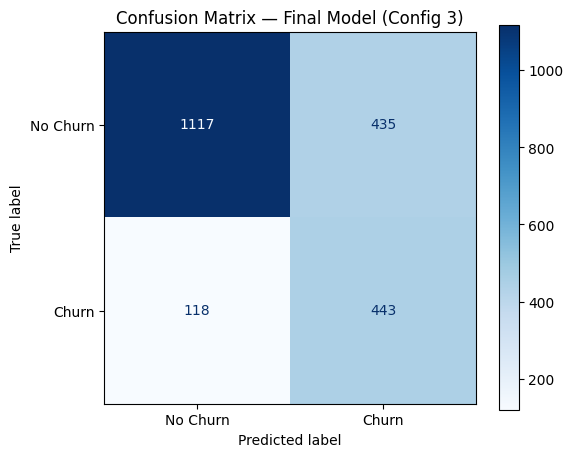

In [147]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

final_model = trained_models["Model Config 3: Moderate depth + balanced"]
y_pred = final_model.predict(X_test_encoded)

# Core metrics (pos_label=1 means "Churn" is the class we're scoring against)
acc = accuracy_score(y_test_encoded, y_pred)
prec = precision_score(y_test_encoded, y_pred, pos_label=1)
rec = recall_score(y_test_encoded, y_pred, pos_label=1)
f1 = f1_score(y_test_encoded, y_pred, pos_label=1)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print()

# Confusion matrix — numbers
cm = confusion_matrix(y_test_encoded, y_pred)
print("Confusion Matrix:")
print(cm)

# Confusion matrix — visual
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Final Model (Config 3)')
plt.show()

## 5. Model Evaluation

**Final Model: Config 3 (max_depth=6, min_samples_leaf=20, class_weight='balanced')**

| Metric | Value |
|--------|-------|
| Accuracy | 0.7383 |
| Precision (Churn) | 0.5046 |
| Recall (Churn) | 0.7897 |
| F1 Score (Churn) | 0.6157 |

**Confusion Matrix:**

|  | Predicted: No Churn | Predicted: Churn |
|---|---|---|
| **Actual: No Churn** | 1117 (TN) | 435 (FP) |
| **Actual: Churn** | 118 (FN) | 443 (TP) |

### Business Interpretation

Out of 561 customers who genuinely churned in the test set, the model
correctly identified 443 of them (79% recall) — meaning the retention team
would receive a proactive alert for roughly 4 out of every 5 at-risk
customers before they leave. Only 118 churners were missed entirely.

In exchange, the model raised 435 false alarms — customers flagged as
at-risk who were not actually going to churn (50% precision). In practice,
this means about half of the retention team's outreach calls would go to
customers who weren't actually leaving.

### Precision vs. Recall: Which matters more for this business?

**Recall is the more important metric for this use case, and we optimized
for it accordingly.**

- A **False Negative** (a missed churner) means the company loses a paying
  customer entirely, with zero chance to intervene — representing lost
  customer lifetime value (LTV), plus the cost of eventually acquiring a
  replacement customer, which is well documented to be more expensive than
  retaining an existing one.
- A **False Positive** (a false alarm) only costs the retention team a
  single, relatively low-cost outreach call to a customer who was never
  going to leave — a minor inefficiency, not a lost customer.

Given this asymmetry — the cost of missing a churner is far higher than the
cost of a false alarm — we deliberately selected Config 3 over Config 2
despite its lower overall accuracy, because it nearly doubles recall (79%
vs. 45%) at an acceptable precision cost. For a telecom retention team, it
is far better to occasionally call a customer who wasn't leaving than to
silently lose 55% of actual churners, as Config 2 would have done.

# Model Interpreatation

                                    feature  importance
28             cat__Contract_Month-to-month    0.562927
41                        remainder__tenure    0.106780
8          cat__InternetService_Fiber optic    0.093748
42                remainder__MonthlyCharges    0.048037
43                  remainder__TotalCharges    0.028516
44               remainder__AvgMonthlySpend    0.026031
19                      cat__TechSupport_No    0.024531
10                   cat__OnlineSecurity_No    0.022555
46             remainder__IsHighRiskProfile    0.017139
11  cat__OnlineSecurity_No internet service    0.015245
29                   cat__Contract_One year    0.012956
31                cat__PaperlessBilling_Yes    0.007264
45         remainder__NumAdditionalServices    0.006471
35          cat__PaymentMethod_Mailed check    0.004716
2                       cat__Dependents_Yes    0.004423


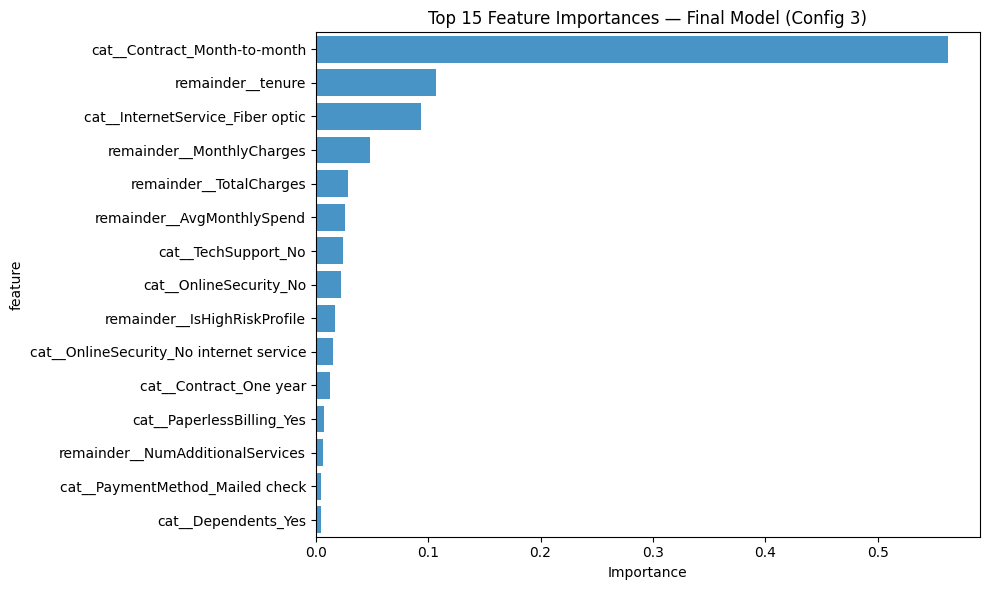

In [148]:
import numpy as np

# Get feature names after one-hot encoding (needed since column names change after encoding)
feature_names = preprocessor.get_feature_names_out()

importances = final_model.feature_importances_

# Build a readable, sorted table
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(importance_df.head(15))

# Visualize top 15
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', color='#3498db')
plt.title('Top 15 Feature Importances — Final Model (Config 3)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

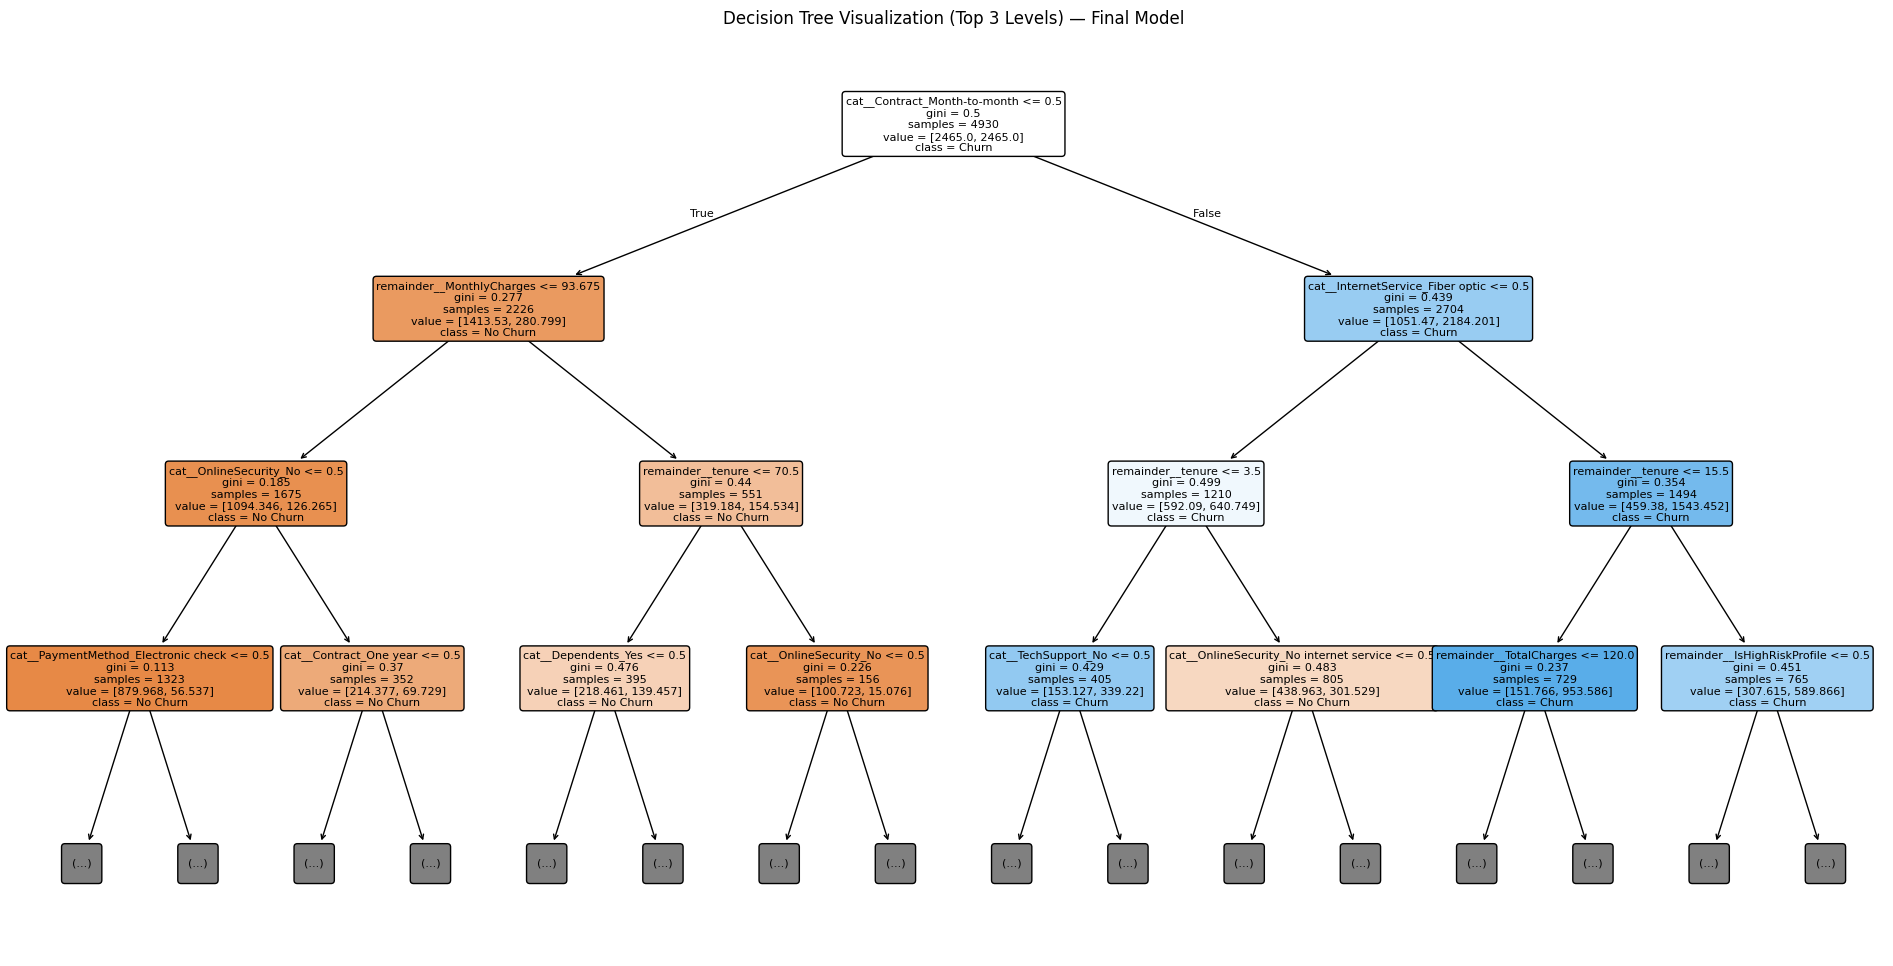

In [149]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))
plot_tree(
    final_model,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title('Decision Tree Visualization (Top 3 Levels) — Final Model')
plt.show()

## 6. Model Interpretation

**Top 5 features by importance:**

| Feature | Importance |
|---------|-----------|
| Contract = Month-to-month | 56.3% |
| tenure | 10.7% |
| InternetService = Fiber optic | 9.4% |
| MonthlyCharges | 4.8% |
| TotalCharges | 2.9% |

**Key findings:**

Contract type is overwhelmingly the strongest predictor of churn, accounting
for over half the model's total decision-making weight, and forms the very
first split at the root of the tree. This directly confirms the EDA finding
that month-to-month customers churn at ~43% versus ~3% for two-year
contracts — the model independently learned the same pattern spotted during
exploratory analysis.

Tenure and Fiber optic internet service form the next-most-influential
factors, also consistent with EDA findings. Together with Contract, these
three features account for over 75% of the model's total decision weight —
suggesting churn at this company is driven primarily by contractual
commitment, customer tenure, and internet service type, rather than a wide
spread of minor factors.

**Business takeaway:** the retention team should prioritize outreach toward
month-to-month customers — especially those also on Fiber optic internet
and early in their tenure — as this combination represents the company's
highest-risk customer profile.

In [150]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

feature_engineer_step = FunctionTransformer(add_engineered_features)

full_pipeline = Pipeline([
    ('feature_engineering', feature_engineer_step),
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=20, class_weight='balanced', random_state=42
    ))
])

X_train_raw = X_train.drop(columns=['TenureGroup', 'AvgMonthlySpend', 'NumAdditionalServices', 'IsHighRiskProfile'])
X_test_raw = X_test.drop(columns=['TenureGroup', 'AvgMonthlySpend', 'NumAdditionalServices', 'IsHighRiskProfile'])

full_pipeline.fit(X_train_raw, y_train_encoded)

from sklearn.metrics import accuracy_score, recall_score
preds = full_pipeline.predict(X_test_raw)
print("Pipeline Accuracy:", accuracy_score(y_test_encoded, preds))
print("Pipeline Recall:", recall_score(y_test_encoded, preds))

Pipeline Accuracy: 0.7382867960246096
Pipeline Recall: 0.7896613190730838


In [151]:
import joblib

joblib.dump(full_pipeline, 'churn_model.pkl')
print("Pipeline saved as churn_model.pkl")

Pipeline saved as churn_model.pkl


In [152]:
import json

# Grab one real customer from the test set as a realistic example
sample_customer = X_test_raw.iloc[0].to_dict()
print(json.dumps(sample_customer, indent=2, default=str))

# Also grab its true label, just so you know what to expect
print("\nActual outcome for this customer:", y_test.iloc[0])

{
  "gender": "Female",
  "SeniorCitizen": 0,
  "Partner": "No",
  "Dependents": "No",
  "tenure": 18,
  "PhoneService": "Yes",
  "MultipleLines": "No",
  "InternetService": "Fiber optic",
  "OnlineSecurity": "Yes",
  "OnlineBackup": "No",
  "DeviceProtection": "No",
  "TechSupport": "No",
  "StreamingTV": "Yes",
  "StreamingMovies": "Yes",
  "Contract": "Month-to-month",
  "PaperlessBilling": "Yes",
  "PaymentMethod": "Electronic check",
  "MonthlyCharges": 96.05,
  "TotalCharges": 1740.7
}

Actual outcome for this customer: Yes


In [153]:
with open('sample_request.json', 'w') as f:
    json.dump(sample_customer, f, indent=2, default=str)

print("Saved sample_request.json")

Saved sample_request.json
